# Load and parse shoreline data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load shoreline dataset
shore = pd.read_csv(
    r"C:\Users\User\Documents\UC\DATA601\Erosion\erosion resources\canterbury_coastsat_monthly_median.csv"
)

# Parse month as datetime
shore["month"] = pd.to_datetime(shore["month"], dayfirst=True)

# Sort for correct differencing
shore = shore.sort_values(["site_id", "transect_id", "month"])

shore.head()


,site_id,transect_id,month,shoreline_pos,n_in_month
0,nzd0382,nzd0382-0000,1999-09-01,329.530,1
1,nzd0382,nzd0382-0000,1999-10-01,340.700,1
2,nzd0382,nzd0382-0000,1999-12-01,336.900,2
3,nzd0382,nzd0382-0000,2000-01-01,335.080,1
4,nzd0382,nzd0382-0000,2000-02-01,335.975,2


@ Compute shoreline change (erosion / accretion)
Scientific rationale

Coastal erosion is not shoreline position, but change in position through time:

Δ
𝑆
𝑡
=
𝑆
𝑡
−
𝑆
𝑡
−
1
ΔS
t
	​

=S
t
	​

−S
t−1
	​


Negative values → erosion

Positive values → accretion

We compute this per transect, not pooled.

# Monthly shoreline change per transect

In [2]:
# Compute monthly shoreline change per transect
shore["shoreline_change"] = (
    shore.groupby(["site_id", "transect_id"])["shoreline_pos"]
    .diff()
)

shore.head(10)


,site_id,transect_id,month,shoreline_pos,n_in_month,shoreline_change
0,nzd0382,nzd0382-0000,1999-09-01,329.530,1,NaN
1,nzd0382,nzd0382-0000,1999-10-01,340.700,1,11.170
2,nzd0382,nzd0382-0000,1999-12-01,336.900,2,-3.800
3,nzd0382,nzd0382-0000,2000-01-01,335.080,1,-1.820
4,nzd0382,nzd0382-0000,2000-02-01,335.975,2,0.895
5,nzd0382,nzd0382-0000,2000-03-01,336.880,1,0.905
6,nzd0382,nzd0382-0000,2000-04-01,336.320,1,-0.560
7,nzd0382,nzd0382-0000,2000-05-01,334.890,1,-1.430
8,nzd0382,nzd0382-0000,2000-06-01,334.870,1,-0.020
9,nzd0382,nzd0382-0000,2000-08-01,335.810,1,0.940


# Visualise shoreline behaviour (all transects)
Why this is important

Before attribution, we must confirm that:

Erosion signals exist

They are episodic (storm-like), not random noise

Transects behave differently (expected)

# Shoreline position vs time (all transects)

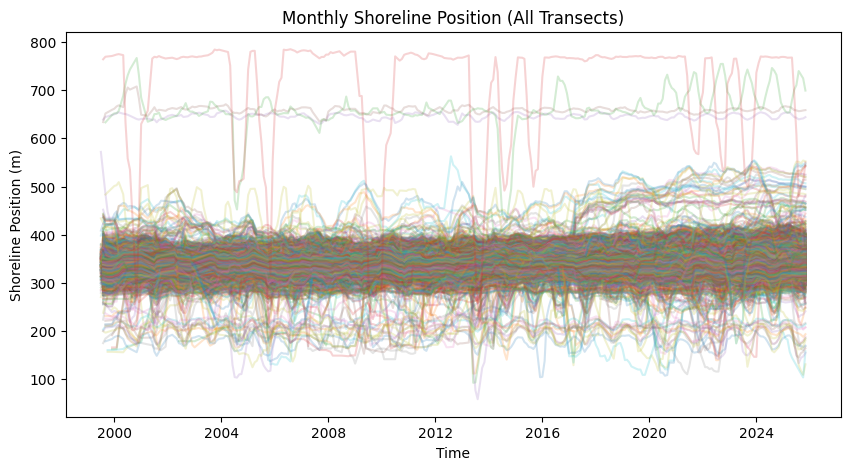

In [3]:
plt.figure(figsize=(10, 5))

for tid, df_t in shore.groupby("transect_id"):
    plt.plot(df_t["month"], df_t["shoreline_pos"], alpha=0.2)

plt.xlabel("Time")
plt.ylabel("Shoreline Position (m)")
plt.title("Monthly Shoreline Position (All Transects)")
plt.show()

# Interpretation

This plot shows:

Long-term trends (chronic erosion/accretion)

Short-term variability (storm response)

Spatial heterogeneity across the coast

This validates the dataset.

# Identify erosion months across the coast
We now define erosion events in a way compatible with storm analysis.

A simple, defensible definition:

shoreline_change < 0 → erosion

More negative → more severe erosion

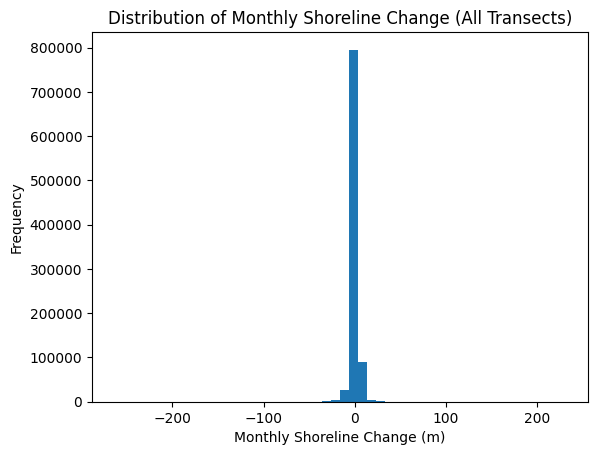

In [4]:
plt.figure()

plt.hist(
    shore["shoreline_change"].dropna(),
    bins=50
)

plt.xlabel("Monthly Shoreline Change (m)")
plt.ylabel("Frequency")
plt.title("Distribution of Monthly Shoreline Change (All Transects)")
plt.show()


# Interpretation

Left tail = erosion-dominated months

Right tail = accretion

Skewness indicates dominance of episodic forcing (storms)

# Aggregate shoreline change spatially (all transects)

Storms affect large coastal sections, not individual transects in isolation.

We therefore compute coast-wide erosion metrics per month.

In [5]:
shore_monthly = (
    shore.groupby("month")["shoreline_change"]
    .mean()
    .reset_index()
)

shore_monthly.rename(
    columns={"shoreline_change": "mean_shoreline_change"},
    inplace=True
)

shore_monthly.head()


,month,mean_shoreline_change
0,1999-07-01,NaN
1,1999-08-01,2.105517
2,1999-09-01,3.266016
3,1999-10-01,3.780714
4,1999-11-01,1.193659


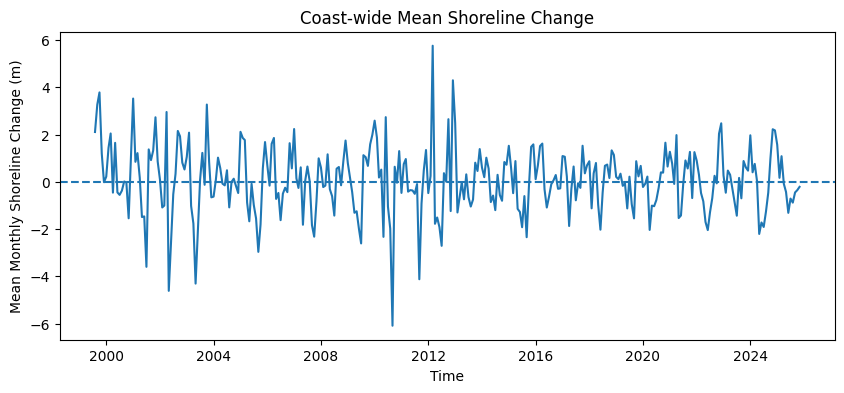

In [6]:
plt.figure(figsize=(10, 4))

plt.plot(
    shore_monthly["month"],
    shore_monthly["mean_shoreline_change"]
)

plt.axhline(0, linestyle="--")
plt.xlabel("Time")
plt.ylabel("Mean Monthly Shoreline Change (m)")
plt.title("Coast-wide Mean Shoreline Change")
plt.show()


In [7]:
transect_erosion = (
    shore.groupby(["site_id", "transect_id"])["shoreline_change"]
    .mean()
    .reset_index()
)

transect_erosion.head()


,site_id,transect_id,shoreline_change
0,nzd0382,nzd0382-0000,0.024477
1,nzd0382,nzd0382-0001,0.059247
2,nzd0382,nzd0382-0002,0.059417
3,nzd0382,nzd0382-0003,0.059958
4,nzd0382,nzd0382-0004,0.050708


In [8]:
# Define output path
output_path = r"C:\Users\User\Documents\UC\DATA601\Erosion\erosion resources\shoreline_change_all_transects.csv"

# Save to CSV
shore.to_csv(output_path, index=False)

print("Saved shoreline change dataset to:")
print(output_path)


Saved shoreline change dataset to:
C:\Users\User\Documents\UC\DATA601\Erosion\erosion resources\shoreline_change_all_transects.csv


In [9]:
pd.read_csv(output_path).head()

,site_id,transect_id,month,shoreline_pos,n_in_month,shoreline_change
0,nzd0382,nzd0382-0000,1999-09-01,329.530,1,NaN
1,nzd0382,nzd0382-0000,1999-10-01,340.700,1,11.170
2,nzd0382,nzd0382-0000,1999-12-01,336.900,2,-3.800
3,nzd0382,nzd0382-0000,2000-01-01,335.080,1,-1.820
4,nzd0382,nzd0382-0000,2000-02-01,335.975,2,0.895
